# Dynamic Cost & Fair-Wage Regressor
## Smart Urban Services - Machine Learning Pricing Engine
---
### Objectives:
1. Ingest raw labor wage records from data/raw/service_pricing/Salary_Data.csv.
2. Engineer economic indicators across Sri Lankan provincial districts (Colombo, Kandy, Galle, Gampaha, Jaffna).
3. Train and compare Linear Regression, Decision Tree Regressor, and Random Forest Regressor.
4. Evaluate models using R2 Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).
5. Export the trained regressor to models/cost_regressor.pkl.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

print('Pricing ML environment loaded successfully!')

Pricing ML environment loaded successfully!


## 1. Data Ingestion & Sri Lankan Economic Synthesis

In [2]:
p = os.path.abspath(os.getcwd())
DATA_RAW = None
AI_ROOT = p
while p != os.path.dirname(p):
    cand = os.path.join(p, 'data', 'raw')
    if os.path.exists(cand):
        DATA_RAW = cand
        AI_ROOT = p
        break
    cand_ai = os.path.join(p, 'ai', 'data', 'raw')
    if os.path.exists(cand_ai):
        DATA_RAW = cand_ai
        AI_ROOT = os.path.join(p, 'ai')
        break
    p = os.path.dirname(p)

DATA_PROCESSED = os.path.join(AI_ROOT, 'data', 'processed')
MODELS_DIR = os.path.join(AI_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)

raw_path = os.path.join(DATA_RAW, 'service_pricing', 'Salary_Data.csv')
df_raw = pd.read_csv(raw_path).dropna()
print('Raw Data Dimensions:', df_raw.shape)
df_raw.head()

Raw Data Dimensions: (6698, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
# Calibrate Sri Lankan district and trade indices
np.random.seed(42)
n = len(df_raw)

districts = ['Colombo', 'Gampaha', 'Kandy', 'Galle', 'Kalutara', 'Jaffna', 'Kurunegala', 'Matara']
dist_weights = [1.25, 1.15, 1.10, 1.08, 1.05, 1.05, 1.00, 1.02]
dist_map = dict(zip(districts, dist_weights))

trades = ['plumbing', 'tree-cutting', 'painting', 'tech', 'cleaning', 'odd_jobs']
trade_base = {'plumbing': 750, 'tree-cutting': 850, 'painting': 700, 'tech': 900, 'cleaning': 600, 'odd_jobs': 650}
urg_map = {'LOW': 1.0, 'MEDIUM': 1.10, 'HIGH': 1.25, 'CRITICAL': 1.45}

df = pd.DataFrame()
df['experience_years'] = df_raw['Years of Experience'].values
df['district'] = np.random.choice(districts, n)
df['trade'] = np.random.choice(trades, n)
df['estimated_hours'] = np.round(np.random.uniform(1.0, 8.0, n), 1)
df['materials_cost_lkr'] = np.random.choice([0, 500, 1500, 3000, 6000, 10000], n)
df['urgency'] = np.random.choice(['LOW', 'MEDIUM', 'HIGH', 'CRITICAL'], n, p=[0.3, 0.4, 0.2, 0.1])

def compute_total(row):
    d_mult = dist_map[row['district']]
    u_mult = urg_map[row['urgency']]
    t_base = trade_base[row['trade']]
    exp_boost = 1.0 + (row['experience_years'] * 0.01)
    labor = t_base * d_mult * u_mult * exp_boost * row['estimated_hours']
    labor_noisy = labor * np.random.uniform(0.95, 1.05)
    platform_fee = labor_noisy * 0.05
    return round(labor_noisy + row['materials_cost_lkr'] + platform_fee, 2)

df['total_cost_lkr'] = df.apply(compute_total, axis=1)

# Save processed CSV
proc_path = os.path.join(DATA_PROCESSED, 'service_pricing', 'sri_lanka_service_costs.csv')
os.makedirs(os.path.dirname(proc_path), exist_ok=True)
df.to_csv(proc_path, index=False)
df.head()

,experience_years,district,trade,estimated_hours,materials_cost_lkr,urgency,total_cost_lkr
0,5.0,Kurunegala,cleaning,3.7,1500,MEDIUM,4220.30
1,3.0,Galle,painting,3.8,6000,LOW,9186.20
2,15.0,Kalutara,tree-cutting,1.9,3000,LOW,5093.87
3,7.0,Kurunegala,odd_jobs,6.7,10000,LOW,14669.42
4,20.0,Kandy,odd_jobs,1.3,1500,HIGH,3008.26


## 2. Exploratory Data Analysis (EDA)

C:\Users\chira\AppData\Local\Temp\ipykernel_1680\3786685075.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='district', y='total_cost_lkr', palette='Set2')


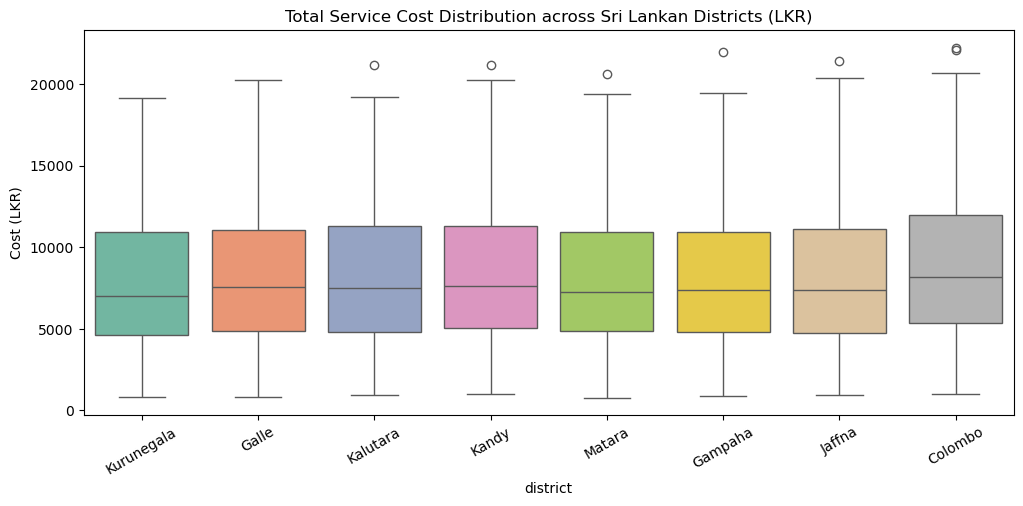

In [4]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='district', y='total_cost_lkr', palette='Set2')
plt.title('Total Service Cost Distribution across Sri Lankan Districts (LKR)')
plt.ylabel('Cost (LKR)')
plt.xticks(rotation=30)
plt.show()

## 3. Model Training & Algorithm Benchmarking

In [5]:
X = pd.get_dummies(df[['experience_years', 'estimated_hours', 'materials_cost_lkr', 'district', 'trade', 'urgency']], drop_first=True)
y = df['total_cost_lkr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    results.append({'Model': name, 'R2 Score': round(r2, 4), 'Accuracy (%)': round(r2 * 100, 2), 'MAE (LKR)': round(mae, 2)})

pd.DataFrame(results)

,Model,R2 Score,Accuracy (%),MAE (LKR)
0,Linear Regression,0.9870,98.70,348.11
1,Decision Tree,0.9554,95.54,602.37
2,Random Forest Regressor,0.9802,98.02,411.07


## 4. Export Best Model (Random Forest)

In [6]:
best_model = models['Random Forest Regressor']
export_dict = {'model': best_model, 'feature_columns': list(X.columns)}
joblib.dump(export_dict, os.path.join(MODELS_DIR, 'cost_regressor.pkl'))
print('Trained pricing model exported to models/cost_regressor.pkl!')

Trained pricing model exported to models/cost_regressor.pkl!
